In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:

# ==========================================
# MODULE 1: DATA PREPROCESSING
# ==========================================
def preprocess_data(filepath):
    """Loads the dataset and prepares features for Machine Learning."""
    df = pd.read_csv(filepath)
    
    # 1. One-Hot Encoding for the categorical 'primary_theme'
    # This transforms text into 0s and 1s so the math engine understands it.
    theme_dummies = pd.get_dummies(df['primary_theme'], prefix='theme')
    
    # 2. Select numerical features for clustering (The Business Logic)
    # We include geographic data AND economic/experiential data
    numerical_features = df[['latitude', 'longitude', 'visit_duration_mins', 
                             'economic_value_mad', 'accessibility_score']]
    
    # 3. Combine them into our final feature matrix (X)
    X_raw = pd.concat([numerical_features, theme_dummies], axis=1)
    
    # 4. Standard Scaler (CRITICAL STEP)
    # This prevents 'economic_value' (up to 700) from crushing 'accessibility' (1 to 5)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    return df, X_scaled


In [4]:

# ==========================================
# MODULE 2: CLUSTERING & DIMENSIONALITY REDUCTION
# ==========================================
def train_ai_models(df, X_scaled, n_clusters=4):
    """Applies K-Means for routing zones and t-SNE for the 'Wow' visual effect."""
    
    # 1. K-Means Clustering
    # Groups POIs into logical daily itineraries based on ALL dimensions
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['route_cluster'] = kmeans.fit_predict(X_scaled)
    
    # 2. t-SNE (t-Distributed Stochastic Neighbor Embedding)
    # Crushes our 8+ dimensions down to 2D just for visualization
    tsne = TSNE(n_components=2, perplexity=10, random_state=42)
    tsne_results = tsne.fit_transform(X_scaled)
    
    df['tsne_x'] = tsne_results[:, 0]
    df['tsne_y'] = tsne_results[:, 1]
    
    return df


In [5]:

# ==========================================
# MODULE 3: THE ROUTING ENGINE (HEURISTIC)
# ==========================================
def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculates simple Euclidean distance for the Nearest Neighbor."""
    return math.sqrt((lat2 - lat1)**2 + (lon2 - lon1)**2)

def generate_caravan_route(df, target_cluster):
    """Uses Nearest Neighbor to draw the logical path within a specific cluster."""
    cluster_points = df[df['route_cluster'] == target_cluster].copy()
    places = cluster_points.to_dict('records')
    route = []
    
    if not places: return route
    
    # Start with the most accessible point (e.g., city center)
    places.sort(key=lambda x: x['accessibility_score'], reverse=True)
    current_place = places.pop(0)
    route.append(current_place)
    
    # Greedy algorithm: always go to the closest next point
    while places:
        nearest_place = min(places, key=lambda p: calculate_distance(
            current_place['latitude'], current_place['longitude'],
            p['latitude'], p['longitude']
        ))
        route.append(nearest_place)
        places.remove(nearest_place)
        current_place = nearest_place
        
    return route


🚀 Starting Masar.AI Intelligence Engine...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


✅ Data processed: 50 historical sites clustered.

🗺️ Sample 'Caravan Route 0' generated with 9 stops.
Start: Monument de l'Indépendance - Marrakech -> End: Monument de l'Évacuation - Boujdour


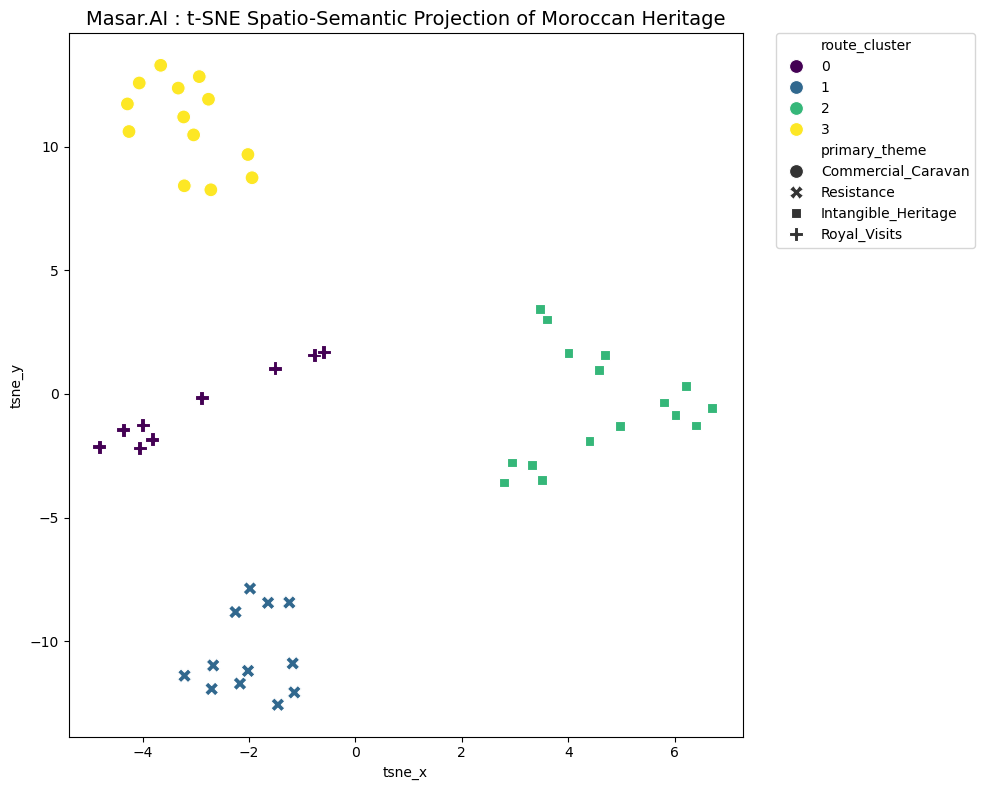

In [6]:


# ==========================================
# MODULE 4: EXECUTION & VISUALIZATION
# ==========================================
if __name__ == "__main__":
    print("🚀 Starting Masar.AI Intelligence Engine...")
    
    # 1. Run the Pipeline
    filepath = "masar_ai_dataset_v3_kaggle.csv" # Ensure your CSV is in the same folder
    df, X_scaled = preprocess_data(filepath)
    df_result = train_ai_models(df, X_scaled, n_clusters=4)
    
    print(f"✅ Data processed: {len(df_result)} historical sites clustered.")
    
    # 2. Test the Routing (Example: Route #0)
    sample_route = generate_caravan_route(df_result, target_cluster=0)
    print(f"\n🗺️ Sample 'Caravan Route 0' generated with {len(sample_route)} stops.")
    print(f"Start: {sample_route[0]['site_name']} -> End: {sample_route[-1]['site_name']}")
    
    # 3. Generate the t-SNE Plot (For your presentation slides!)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='tsne_x', y='tsne_y', 
        hue='route_cluster', 
        style='primary_theme',
        palette='viridis', 
        s=100, 
        data=df_result
    )
    plt.title("Masar.AI : t-SNE Spatio-Semantic Projection of Moroccan Heritage", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.show()
    # Save this plot! It proves your AI understands deep relationships.